
# Uczenie maszynowe — zajęcia 2
## Principal Component Analysis (PCA) — część 2: projekcja i redukcja wymiarowości

**Uniwersytet Warmińsko-Mazurski w Olsztynie**  
**Semestr 5, rok akademicki 2026/2027**  
**Prowadzący: mgr inż. Adrian Albrecht**

---

### Cel zajęć

Na poprzednich zajęciach wyznaczyliśmy:

- średnie cech,
- dane wycentrowane,
- macierz kowariancji,
- wartości własne,
- wektory własne,
- uporządkowane główne składowe.

Na dzisiejszych zajęciach wykorzystamy te elementy do **faktycznej redukcji wymiarowości**.

Po zajęciach osoba studiująca powinna umieć:

1. wybrać określoną liczbę głównych składowych,
2. zbudować macierz projekcji,
3. przekształcić dane do nowej przestrzeni,
4. zredukować dane z 4 do 3 oraz 2 wymiarów,
5. interpretować udział zmienności,
6. zwizualizować dane po PCA,
7. porównać własną implementację z `sklearn.decomposition.PCA`,
8. wyjaśnić, dlaczego redukcja wymiarowości powoduje utratę części informacji.

> **Ważne:** gotowa implementacja `sklearn.decomposition.PCA` pojawi się dopiero na końcu i będzie wykorzystana wyłącznie do weryfikacji własnej implementacji.



## Plan zajęć — 90 minut

| Czas | Temat |
|---:|---|
| 0–10 min | Przypomnienie poprzednich zajęć |
| 10–25 min | Wybór głównych składowych i macierz projekcji |
| 25–40 min | Projekcja danych do 3D i 2D |
| 40–55 min | Udział zmienności i decyzja o liczbie składowych |
| 55–70 min | Wizualizacja wyniku |
| 70–80 min | Własna klasa `MyPCA` |
| 80–87 min | Porównanie ze `sklearn.PCA` |
| 87–90 min | Podsumowanie + zadanie samodzielne |



# 0. Przygotowanie środowiska


In [20]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

np.set_printoptions(precision=4, suppress=True)



# 1. Przypomnienie — gdzie skończyliśmy?

Na poprzednich zajęciach wykonaliśmy następujące kroki:

```text
DANE
  │
  ▼
średnia każdej cechy
  │
  ▼
centrowanie danych
  │
  ▼
macierz kowariancji
  │
  ▼
wartości własne + wektory własne
  │
  ▼
sortowanie malejąco według wartości własnych
```

Dzisiaj dodamy:

```text
wybór k składowych
  │
  ▼
macierz projekcji
  │
  ▼
projekcja danych
  │
  ▼
dane o mniejszej liczbie wymiarów
```


In [21]:

iris = load_iris()

X = iris.data
y = iris.target

print("Kształt danych:", X.shape)
print("Nazwy cech:", iris.feature_names)


Kształt danych: (150, 4)
Nazwy cech: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



## 1.1. Odtworzenie kroków z poprzednich zajęć

Najpierw wykonujemy dokładnie te operacje, które poznaliśmy wcześniej.


In [22]:

# 1. Średnie
mean_vector = np.mean(X, axis=0)

# 2. Centrowanie
X_centered = X - mean_vector

# 3. Macierz kowariancji
n = X_centered.shape[0]

covariance_matrix = (
    X_centered.T @ X_centered
) / (n - 1)

# 4. Wartości i wektory własne
eigenvalues, eigenvectors = np.linalg.eigh(
    covariance_matrix
)

# 5. Sortowanie malejąco
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Wartości własne:")
print(eigenvalues)

print("\nWektory własne:")
print(eigenvectors)


Wartości własne:
[4.2282 0.2427 0.0782 0.0238]

Wektory własne:
[[-0.3614  0.6566  0.582   0.3155]
 [ 0.0845  0.7302 -0.5979 -0.3197]
 [-0.8567 -0.1734 -0.0762 -0.4798]
 [-0.3583 -0.0755 -0.5458  0.7537]]



# 2. Wybór głównych składowych

Każdy wektor własny opisuje jeden nowy kierunek.

Jeżeli chcemy zmniejszyć liczbę wymiarów z 4 do 2, wybieramy dwa wektory własne odpowiadające dwóm największym wartościom własnym.

Tworzą one macierz projekcji:

$$
W=
\begin{bmatrix}
| & |\\
v_1 & v_2\\
| & |
\end{bmatrix}
$$

Dla danych Iris macierz wejściowa ma rozmiar:

$$
150 \times 4
$$

a macierz projekcji dla dwóch składowych:

$$
4 \times 2
$$

Po przemnożeniu otrzymamy:

$$
(150 \times 4)(4 \times 2)=150 \times 2
$$

czyli 150 obserwacji opisanych już tylko dwiema nowymi cechami.


In [23]:

# Dwie najważniejsze składowe

W_2 = eigenvectors[:, :2]

print("Macierz projekcji W dla 2 składowych:")
print(W_2)

print("\nKształt W:")
print(W_2.shape)


Macierz projekcji W dla 2 składowych:
[[-0.3614  0.6566]
 [ 0.0845  0.7302]
 [-0.8567 -0.1734]
 [-0.3583 -0.0755]]

Kształt W:
(4, 2)



## 2.1. Co zawiera macierz projekcji?

Każda kolumna macierzy `W_2` jest jednym wektorem własnym.

Pierwsza kolumna opisuje pierwszą główną składową.

Druga kolumna opisuje drugą główną składową.

Nie są to dwie wybrane cechy ze zbioru Iris.

Są to nowe kierunki zbudowane na podstawie wszystkich czterech cech.


In [24]:

components_df = pd.DataFrame(
    W_2,
    index=iris.feature_names,
    columns=["PC1", "PC2"]
)

display(components_df)


,PC1,PC2
sepal length (cm),-0.361387,0.656589
sepal width (cm),0.084523,0.730161
petal length (cm),-0.856671,-0.173373
petal width (cm),-0.358289,-0.075481



# 3. Projekcja danych

Mamy:

- dane wycentrowane,
- wybrane główne składowe.

Możemy więc wykonać projekcję:

$$
X_{PCA}=X_cW
$$

gdzie:

- `X_c` — dane wycentrowane,
- `W` — macierz wybranych wektorów własnych,
- `X_PCA` — dane zapisane w nowym układzie współrzędnych.


In [25]:

X_pca_2 = X_centered @ W_2

print("Oryginalny kształt:")
print(X.shape)

print("\nKształt po PCA do 2 wymiarów:")
print(X_pca_2.shape)

print("\nPierwsze 5 obserwacji po transformacji:")
print(X_pca_2[:5])


Oryginalny kształt:
(150, 4)

Kształt po PCA do 2 wymiarów:
(150, 2)

Pierwsze 5 obserwacji po transformacji:
[[ 2.6841  0.3194]
 [ 2.7141 -0.177 ]
 [ 2.889  -0.1449]
 [ 2.7453 -0.3183]
 [ 2.7287  0.3268]]



Właśnie wykonaliśmy właściwą redukcję wymiarowości:

$$
4D \rightarrow 2D
$$

Każda obserwacja nadal istnieje.

Zmieniła się natomiast liczba współrzędnych opisujących tę obserwację.



# 4. Redukcja do trzech wymiarów

Analogicznie możemy zachować trzy najważniejsze składowe.

Macierz projekcji będzie miała wtedy rozmiar:

$$
4 \times 3
$$

a wynik:

$$
150 \times 3
$$


In [26]:

W_3 = eigenvectors[:, :3]

X_pca_3 = X_centered @ W_3

print("Kształt po PCA do 3 wymiarów:")
print(X_pca_3.shape)

print("\nPierwsze 5 obserwacji:")
print(X_pca_3[:5])


Kształt po PCA do 3 wymiarów:
(150, 3)

Pierwsze 5 obserwacji:
[[ 2.6841  0.3194  0.0279]
 [ 2.7141 -0.177   0.2105]
 [ 2.889  -0.1449 -0.0179]
 [ 2.7453 -0.3183 -0.0316]
 [ 2.7287  0.3268 -0.0901]]



### Pytanie kontrolne

Czy redukcja:

$$
4D \rightarrow 3D
$$

musi zachować więcej informacji niż:

$$
4D \rightarrow 2D
$$

Jeżeli składowe są uporządkowane według malejących wartości własnych — tak.

Trzecia składowa dodaje kolejną porcję zmienności, której nie ma w reprezentacji dwuwymiarowej.



# 5. Udział zmienności

Wartość własna informuje nas, ile zmienności znajduje się w danym kierunku.

Udział zmienności konkretnej składowej możemy obliczyć:

$$
r_i=
\frac{\lambda_i}
{\sum_j \lambda_j}
$$

Suma wszystkich udziałów wynosi:

$$
\sum_i r_i = 1
$$


In [27]:

explained_variance_ratio = (
    eigenvalues /
    eigenvalues.sum()
)

cumulative_variance = np.cumsum(
    explained_variance_ratio
)

variance_df = pd.DataFrame({
    "składowa": [
        f"PC{i+1}"
        for i in range(len(eigenvalues))
    ],
    "wartość własna": eigenvalues,
    "udział zmienności": explained_variance_ratio,
    "udział skumulowany": cumulative_variance
})

display(variance_df)


,składowa,wartość własna,udział zmienności,udział skumulowany
0,PC1,4.228242,0.924619,0.924619
1,PC2,0.242671,0.053066,0.977685
2,PC3,0.078210,0.017103,0.994788
3,PC4,0.023835,0.005212,1.000000



## 5.1. Ile informacji zachowujemy?

Dla dwóch składowych zachowujemy łączny udział:

$$
r_1+r_2
$$

Dla trzech składowych:

$$
r_1+r_2+r_3
$$

Nie oznacza to dosłownie „procentu wszystkich informacji”, ale jest wygodnym opisem tego, jaka część całkowitej wariancji pozostaje w wybranej reprezentacji.


In [28]:

variance_2d = explained_variance_ratio[:2].sum()
variance_3d = explained_variance_ratio[:3].sum()

print(
    "Udział zmienności zachowany w 2D:",
    round(variance_2d, 4)
)

print(
    "Udział zmienności zachowany w 3D:",
    round(variance_3d, 4)
)


Udział zmienności zachowany w 2D: 0.9777
Udział zmienności zachowany w 3D: 0.9948


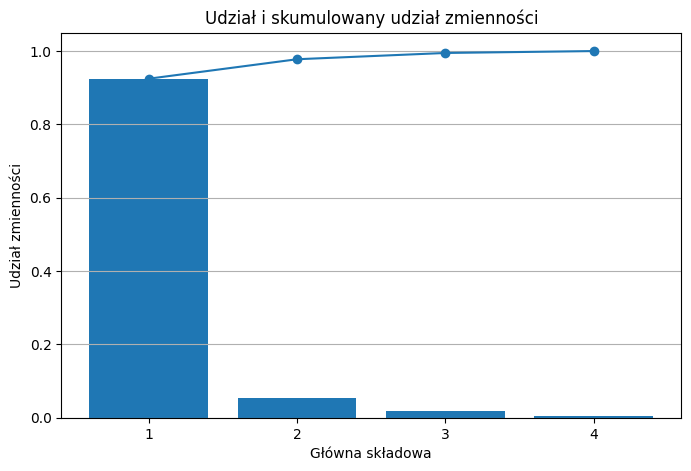

In [29]:

plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio
)

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Główna składowa")
plt.ylabel("Udział zmienności")
plt.title("Udział i skumulowany udział zmienności")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(axis="y")
plt.show()



### Ważna uwaga

Nie istnieje jedna uniwersalna liczba głównych składowych, którą zawsze należy zachować.

Decyzja zależy między innymi od:

- celu analizy,
- liczby oryginalnych cech,
- rozkładu wartości własnych,
- tego, ile zmienności chcemy zachować,
- tego, czy zależy nam na wizualizacji,
- tego, jak bardzo możemy zaakceptować uproszczenie danych.

PCA jest kompromisem pomiędzy **prostszą reprezentacją** a **utratą części zmienności**.



# 6. Wizualizacja PCA w dwóch wymiarach

Dzięki redukcji do dwóch wymiarów możemy teraz narysować cały zbiór Iris na jednym wykresie.

Kolory wykorzystamy wyłącznie do wizualizacji rzeczywistych klas.

Etykiety klas **nie brały udziału w PCA**.


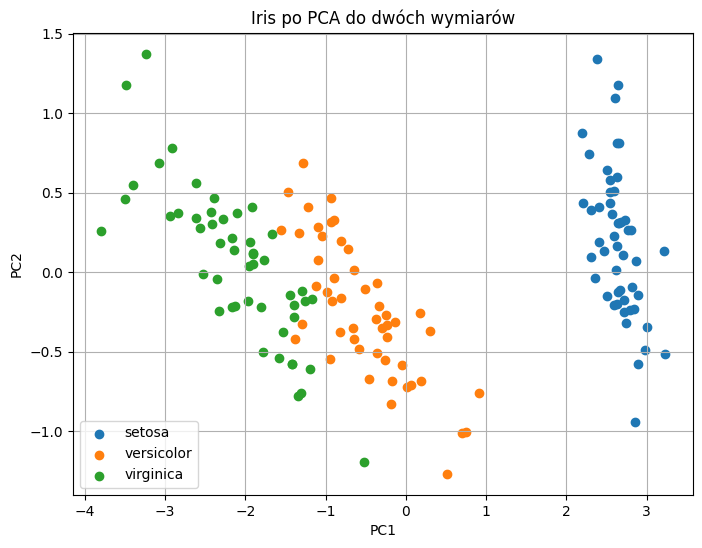

In [30]:

plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(iris.target_names):
    mask = y == class_id

    plt.scatter(
        X_pca_2[mask, 0],
        X_pca_2[mask, 1],
        label=class_name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris po PCA do dwóch wymiarów")
plt.legend()
plt.grid()
plt.show()



### Pytania do wykresu

1. Czy wszystkie trzy klasy są równie dobrze odseparowane?
2. Czy PCA znało klasy podczas tworzenia nowych osi?
3. Dlaczego mimo braku etykiet część klas może być widocznie rozdzielona?
4. Czy celem PCA jest maksymalizacja separacji klas?

Odpowiedź na ostatnie pytanie brzmi: **nie**.

PCA maksymalizuje opisywaną zmienność, a nie separację klas.



# 7. Wizualizacja PCA w trzech wymiarach

Redukcja do trzech składowych zachowuje więcej zmienności niż redukcja do dwóch.

Możemy również zwizualizować wynik w przestrzeni 3D.


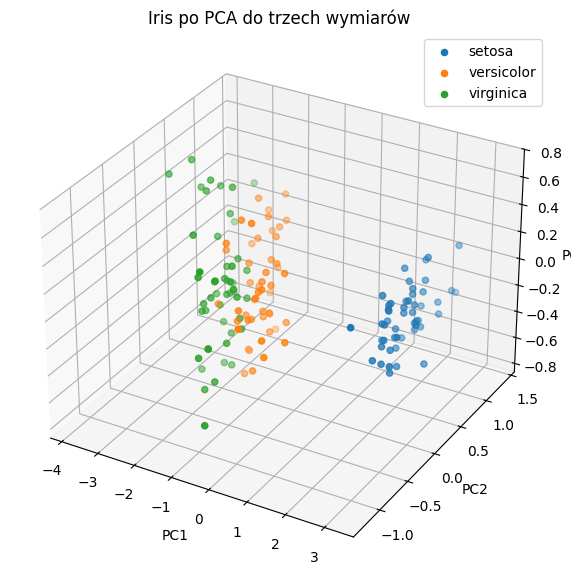

In [31]:

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for class_id, class_name in enumerate(iris.target_names):
    mask = y == class_id

    ax.scatter(
        X_pca_3[mask, 0],
        X_pca_3[mask, 1],
        X_pca_3[mask, 2],
        label=class_name
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Iris po PCA do trzech wymiarów")
ax.legend()

plt.show()



# 8. Czy po PCA można odzyskać dane?

Jeżeli zachowamy wszystkie główne składowe, transformacja jest zmianą układu współrzędnych i dane można odtworzyć z bardzo dużą dokładnością numeryczną.

Jeżeli jednak zachowamy tylko część składowych, część informacji zostanie utracona.

Dla wybranych składowych przybliżone odtworzenie danych ma postać:

$$
\hat{X}=X_{PCA}W^T+\mu
$$

gdzie:

- `X_PCA` — dane po redukcji,
- `W` — macierz wybranych składowych,
- `μ` — wektor średnich.


In [32]:

X_reconstructed_2 = (
    X_pca_2 @ W_2.T
) + mean_vector

print("Pierwsza oryginalna obserwacja:")
print(X[0])

print("\nTa sama obserwacja odtworzona z 2 składowych:")
print(X_reconstructed_2[0])


Pierwsza oryginalna obserwacja:
[5.1 3.5 1.4 0.2]

Ta sama obserwacja odtworzona z 2 składowych:
[5.083  3.5174 1.4032 0.2135]



Wynik nie jest identyczny z oryginałem, ponieważ dwie słabsze składowe zostały odrzucone.

To bardzo praktyczny sposób pokazania, że redukcja wymiarowości jest **kompresją stratną**.



## 8.1. Dodatkowy eksperyment — rekonstrukcja z różnej liczby składowych

Ta część może zostać wykonana samodzielnie po zajęciach.

Porównaj odtworzenie danych dla:

- 1 składowej,
- 2 składowych,
- 3 składowych,
- 4 składowych.

Sprawdź, jak zmienia się różnica pomiędzy danymi oryginalnymi i odtworzonymi.


In [33]:

for k in [1, 2, 3, 4]:

    W_k = eigenvectors[:, :k]

    X_pca_k = X_centered @ W_k

    X_reconstructed_k = (
        X_pca_k @ W_k.T
    ) + mean_vector

    reconstruction_error = np.mean(
        (X - X_reconstructed_k) ** 2
    )

    print(
        f"k={k}, średni kwadrat błędu rekonstrukcji = "
        f"{reconstruction_error:.6f}"
    )


k=1, średni kwadrat błędu rekonstrukcji = 0.085604
k=2, średni kwadrat błędu rekonstrukcji = 0.025341
k=3, średni kwadrat błędu rekonstrukcji = 0.005919
k=4, średni kwadrat błędu rekonstrukcji = 0.000000



# 9. Własna klasa `MyPCA`

Po przejściu całego algorytmu krok po kroku możemy zamknąć go w klasie.

Klasa powinna:

- zapamiętać średnie cech,
- wyznaczyć macierz kowariancji,
- wyznaczyć i posortować wartości własne,
- zapamiętać wybrane główne składowe,
- umożliwiać transformację nowych danych.


In [34]:
from myPCA import MyPCA

In [35]:

my_pca = MyPCA(
    n_components=2
)

X_my_pca = my_pca.fit_transform(
    X
)

print("Kształt po transformacji:")
print(X_my_pca.shape)

print("\nPierwsze 5 obserwacji:")
print(X_my_pca[:5])

print("\nUdział zmienności:")
print(my_pca.explained_variance_ratio_)


Kształt po transformacji:
(150, 2)

Pierwsze 5 obserwacji:
[[ 2.6841  0.3194]
 [ 2.7141 -0.177 ]
 [ 2.889  -0.1449]
 [ 2.7453 -0.3183]
 [ 2.7287  0.3268]]

Udział zmienności:
[0.9246 0.0531 0.0171 0.0052]



# 10. Weryfikacja za pomocą `sklearn.PCA`

Dopiero teraz, po własnej implementacji, wykorzystamy gotowe PCA.

Nie jest to rozwiązanie zadania.

Służy wyłącznie do sprawdzenia, czy nasza implementacja daje zgodne rezultaty.


In [36]:

from sklearn.decomposition import PCA

sklearn_pca = PCA(
    n_components=2
)

X_sklearn = sklearn_pca.fit_transform(
    X
)

print("Udział zmienności — własna implementacja:")
print(
    my_pca.explained_variance_ratio_[:2]
)

print("\nUdział zmienności — sklearn:")
print(
    sklearn_pca.explained_variance_ratio_
)


Udział zmienności — własna implementacja:
[0.9246 0.0531]

Udział zmienności — sklearn:
[0.9246 0.0531]



## 10.1. Dlaczego współrzędne mogą mieć przeciwny znak?

Wektor własny i jego przeciwieństwo opisują ten sam kierunek:

$$
v
$$

oraz

$$
-v
$$

są równoważnymi rozwiązaniami problemu wektora własnego.

Dlatego własna implementacja i `sklearn` mogą zwrócić współrzędne różniące się znakiem.

Nie oznacza to błędu.


In [37]:

print("Pierwsze 5 obserwacji — MyPCA:")
print(X_my_pca[:5])

print("\nPierwsze 5 obserwacji — sklearn:")
print(X_sklearn[:5])


Pierwsze 5 obserwacji — MyPCA:
[[ 2.6841  0.3194]
 [ 2.7141 -0.177 ]
 [ 2.889  -0.1449]
 [ 2.7453 -0.3183]
 [ 2.7287  0.3268]]

Pierwsze 5 obserwacji — sklearn:
[[-2.6841  0.3194]
 [-2.7141 -0.177 ]
 [-2.889  -0.1449]
 [-2.7453 -0.3183]
 [-2.7287  0.3268]]



Możemy porównać wartości bezwzględne współrzędnych.

Jeżeli różnica wynika wyłącznie z odwrócenia kierunku osi, wartości bezwzględne powinny być bardzo zbliżone.


In [38]:

print(
    np.allclose(
        np.abs(X_my_pca),
        np.abs(X_sklearn)
    )
)


True



# 11. Pełny algorytm PCA

Po dwóch zajęciach znamy już cały przebieg:

```text
DANE
  │
  ▼
obliczenie średnich
  │
  ▼
centrowanie
  │
  ▼
macierz kowariancji
  │
  ▼
wartości i wektory własne
  │
  ▼
sortowanie według wartości własnych
  │
  ▼
wybór k głównych składowych
  │
  ▼
macierz projekcji W
  │
  ▼
X_PCA = X_centered @ W
  │
  ▼
DANE O MNIEJSZEJ LICZBIE WYMIARÓW
```



# 12. Zadanie samodzielne

Przygotuj własny skrypt lub notebook, w którym:

1. wykorzystasz zbiór Iris,
2. wykonasz PCA własną implementacją,
3. zredukujesz dane:
   - do 3 wymiarów,
   - do 2 wymiarów,
4. wyświetlisz:
   - wartości własne,
   - udział zmienności każdej składowej,
   - udział skumulowany,
5. przygotujesz wykres 2D,
6. przygotujesz wykres 3D,
7. krótko odpowiesz na pytania:
   - ile zmienności zachowano po redukcji do 2D?
   - ile po redukcji do 3D?
   - co zostało utracone?
   - dlaczego PCA nie potrzebuje informacji o klasach?
   - dlaczego wynik własnej implementacji może różnić się znakiem od wyniku `sklearn`?

### Warunek

Właściwa implementacja PCA ma być wykonana samodzielnie.

Gotowa implementacja `sklearn.PCA` może być użyta wyłącznie do końcowego sprawdzenia wyniku.



# 13. Pytania podsumowujące

Po tych zajęciach powinieneś/powinnaś umieć odpowiedzieć na następujące pytania:

1. Co oznacza macierz projekcji?
2. Dlaczego jej kolumnami są wektory własne?
3. Dlaczego wybieramy wektory związane z największymi wartościami własnymi?
4. Jak wygląda wzór na projekcję danych?
5. Jaki będzie wymiar wyniku dla danych `150 × 4` i trzech głównych składowych?
6. Czy redukcja do dwóch wymiarów jest bezstratna?
7. Co oznacza udział zmienności danej składowej?
8. Czy większa liczba składowych zawsze zachowuje więcej zmienności?
9. Czy PCA maksymalizuje separację klas?
10. Dlaczego możemy użyć etykiet klas do wizualizacji wyniku, mimo że PCA ich nie wykorzystuje?
11. Dlaczego dwa poprawne wyniki PCA mogą różnić się znakiem?
12. Czy PCA pozwala odtworzyć oryginalne dane?
13. Kiedy rekonstrukcja jest dokładna?
14. Dlaczego redukcja wymiarowości może być traktowana jako kompresja stratna?
15. Co musi zostać zapamiętane w metodzie `fit`, aby później można było wykonać `transform` na nowych danych?



# 14. Najważniejsze wnioski

> **PCA nie usuwa po prostu „najgorszych kolumn”. Tworzy nowy układ współrzędnych.**

> **Główne składowe są uporządkowane według ilości opisywanej zmienności.**

> **Redukcja wymiarowości polega na pozostawieniu tylko części nowych osi.**

> **Im mniej składowych zachowamy, tym prostsza reprezentacja danych, ale potencjalnie większa utrata informacji.**

Na kolejnych zajęciach przechodzimy do **Support Vector Machines**.
